# Ejemplo de uso

In [1]:
from minisom import MiniSom
import pandas as pd
import numpy as np
columns=['area', 'perimeter', 'compactness', 'length_kernel', 'width_kernel',
                   'asymmetry_coefficient', 'length_kernel_groove', 'target']
data = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/00236/seeds_dataset.txt', 
                    names=columns, 
                   sep='\t+', engine='python')
target = data['target'].values
label_names = {1:'Kama', 2:'Rosa', 3:'Canadian'}
data = data[data.columns[:-1]]
# data normalization
data = (data - np.mean(data, axis=0)) / np.std(data, axis=0)
data = data.values

In [2]:
# Initialization and training
n_neurons = 9
m_neurons = 9
som = MiniSom(n_neurons, m_neurons, data.shape[1], sigma=1.5, learning_rate=.5, 
              neighborhood_function='gaussian', random_seed=0, topology='rectangular')

som.pca_weights_init(data)
som.train(data, 1000, verbose=True)  # random training

 [ 1000 / 1000 ] 100% - 0:00:00 left 
 quantization error: 0.506671895909233


C:\Users\abril\anaconda3\lib\site-packages\minisom.py:388: ComplexWarning: Casting complex values to real discards the imaginary part
  self._weights[i, j] = c1*pc[pc_order[0]] + \


In [3]:
som.topographic_error(data[:100])

0.08

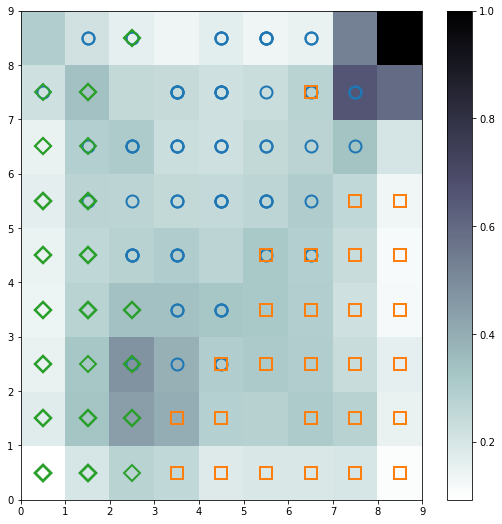

In [4]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(9, 9))

plt.pcolor(som.distance_map().T, cmap='bone_r')  # plotting the distance map as background
plt.colorbar()

# Plotting the response for each pattern in the iris dataset
# different colors and markers for each label
markers = ['o', 's', 'D']
colors = ['C0', 'C1', 'C2']
for cnt, xx in enumerate(data):
    w = som.winner(xx)  # getting the winner
    # palce a marker on the winning position for the sample xx
    plt.plot(w[0]+.5, w[1]+.5, markers[target[cnt]-1], markerfacecolor='None',
             markeredgecolor=colors[target[cnt]-1], markersize=12, markeredgewidth=2)

plt.show()

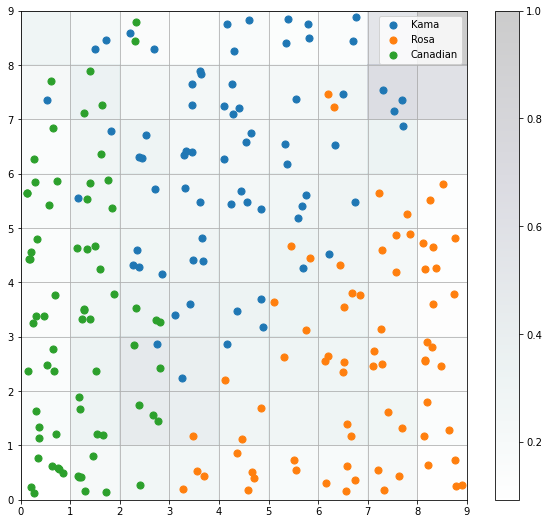

In [5]:
w_x, w_y = zip(*[som.winner(d) for d in data])
w_x = np.array(w_x)
w_y = np.array(w_y)

plt.figure(figsize=(10, 9))
plt.pcolor(som.distance_map().T, cmap='bone_r', alpha=.2)
plt.colorbar()

for c in np.unique(target):
    idx_target = target==c
    plt.scatter(w_x[idx_target]+.5+(np.random.rand(np.sum(idx_target))-.5)*.8,
                w_y[idx_target]+.5+(np.random.rand(np.sum(idx_target))-.5)*.8, 
                s=50, c=colors[c-1], label=label_names[c])
plt.legend(loc='upper right')
plt.grid()
plt.show()

# Verificación de que el espacio de muestras para entrenar a los SOMs tiene una distribución gaussiana:

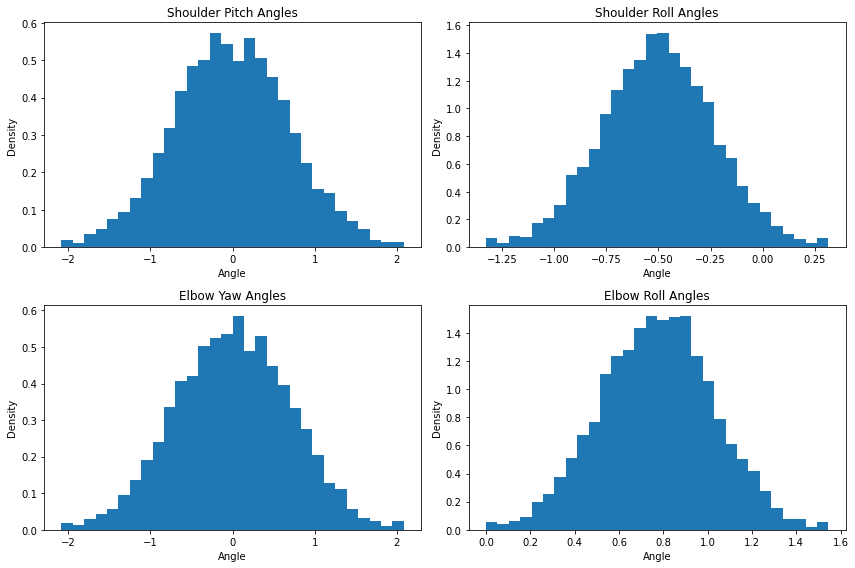

Shapiro-Wilk Test Results:
Shoulder Pitch: ShapiroResult(statistic=0.9993278980255127, pvalue=0.057881321758031845)
Shoulder Roll: ShapiroResult(statistic=0.9992649555206299, pvalue=0.03532811999320984)
Elbow Yaw: ShapiroResult(statistic=0.9992372393608093, pvalue=0.028398709371685982)
Elbow Roll: ShapiroResult(statistic=0.9993346929550171, pvalue=0.06103237718343735)


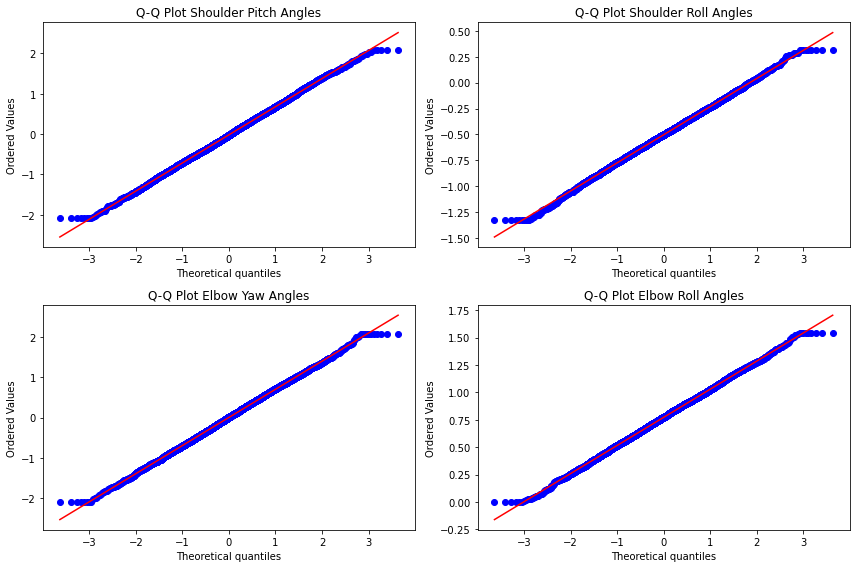

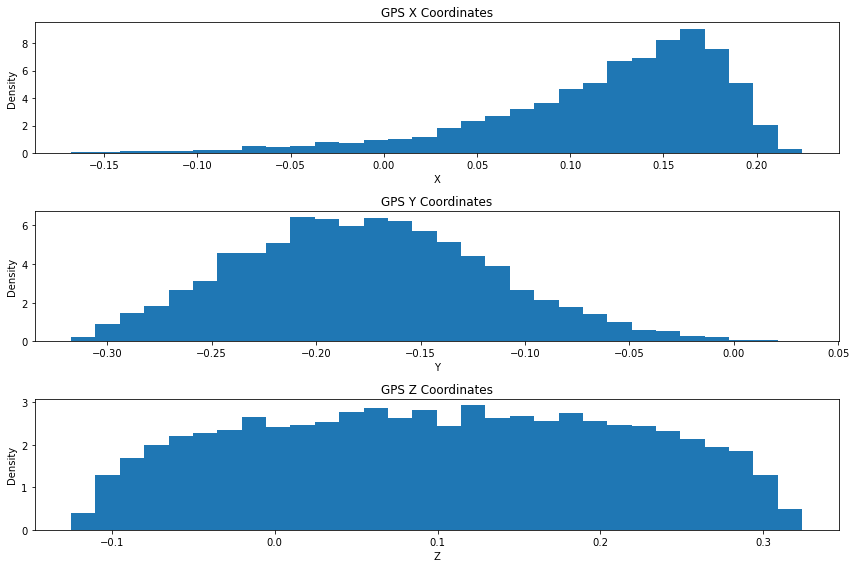

Shapiro-Wilk Test Results for GPS Data:
GPS X: ShapiroResult(statistic=0.9030889868736267, pvalue=0.0)
GPS Y: ShapiroResult(statistic=0.9943163394927979, pvalue=3.6255246309464806e-13)
GPS Z: ShapiroResult(statistic=0.9696370959281921, pvalue=2.882192247792465e-31)


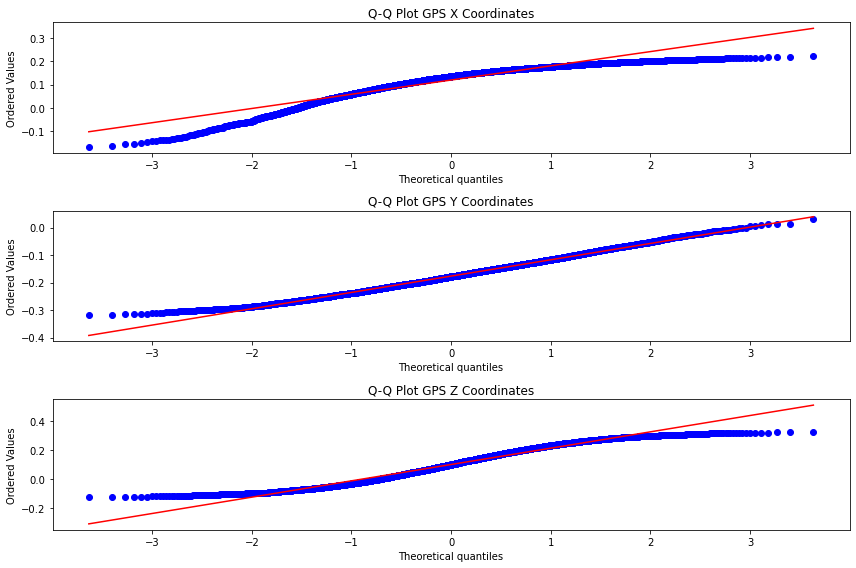

In [1]:
import random
import csv
import time
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

# Initialize lists to store the generated angles and GPS data
shoulder_pitch_angles = []
shoulder_roll_angles = []
elbow_yaw_angles = []
elbow_roll_angles = []

gps_x = []
gps_y = []
gps_z = []

motor_data = []
gps_data = []
    
with open("my_project\controllers\my_controller\motor_angles.csv", "r", newline='') as motor_csvfile:
    motor_reader = csv.reader(motor_csvfile)
   
    for row in motor_reader:
        motor_data.append([float(value) for value in row[1:]])  # Pasar la columna del indice
    
# Leer los datos del GPS del CSV
with open("my_project\controllers\my_controller\gps_hand.csv", "r", newline='') as gps_csvfile:
    gps_reader = csv.reader(gps_csvfile)
   
    for row in gps_reader:
        gps_data.append([float(value) for value in row[1:]])  # Pasar la columna del indice
            
# Assign the motor data to the respective angle lists
for data in motor_data:
    shoulder_pitch_angles.append(data[0])
    shoulder_roll_angles.append(data[1])
    elbow_yaw_angles.append(data[2])
    elbow_roll_angles.append(data[3])
    
# Assign the motor data to the respective angle lists
for data in gps_data:
    gps_x.append(data[0])
    gps_y.append(data[1])
    gps_z.append(data[2])

#Print the lists to verify the data
#print("Shoulder Pitch Angles:", shoulder_pitch_angles)
#print("GPS_x:", gps_x)

# Plot histograms-angles
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.hist(shoulder_pitch_angles, bins=30, density=True)
plt.title("Shoulder Pitch Angles")
plt.xlabel("Angle")
plt.ylabel("Density")

plt.subplot(2, 2, 2)
plt.hist(shoulder_roll_angles, bins=30, density=True)
plt.title("Shoulder Roll Angles")
plt.xlabel("Angle")
plt.ylabel("Density")

plt.subplot(2, 2, 3)
plt.hist(elbow_yaw_angles, bins=30, density=True)
plt.title("Elbow Yaw Angles")
plt.xlabel("Angle")
plt.ylabel("Density")

plt.subplot(2, 2, 4)
plt.hist(elbow_roll_angles, bins=30, density=True)
plt.title("Elbow Roll Angles")
plt.xlabel("Angle")
plt.ylabel("Density")

plt.tight_layout()
plt.show()

#Perform Shapiro-Wilk test
print("Shapiro-Wilk Test Results:")
print(f"Shoulder Pitch: {stats.shapiro(shoulder_pitch_angles)}")
print(f"Shoulder Roll: {stats.shapiro(shoulder_roll_angles)}")
print(f"Elbow Yaw: {stats.shapiro(elbow_yaw_angles)}")
print(f"Elbow Roll: {stats.shapiro(elbow_roll_angles)}")

#Plot Q-Q plots
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
stats.probplot(shoulder_pitch_angles, dist="norm", plot=plt)
plt.title("Q-Q Plot Shoulder Pitch Angles")

plt.subplot(2, 2, 2)
stats.probplot(shoulder_roll_angles, dist="norm", plot=plt)
plt.title("Q-Q Plot Shoulder Roll Angles")

plt.subplot(2, 2, 3)
stats.probplot(elbow_yaw_angles, dist="norm", plot=plt)
plt.title("Q-Q Plot Elbow Yaw Angles")

plt.subplot(2, 2, 4)
stats.probplot(elbow_roll_angles, dist="norm", plot=plt)
plt.title("Q-Q Plot Elbow Roll Angles")

plt.tight_layout()
plt.show()

# Plot histograms-gps
plt.figure(figsize=(12, 8))

plt.subplot(3, 1, 1)
plt.hist(gps_x, bins=30, density=True)
plt.title("GPS X Coordinates")
plt.xlabel("X")
plt.ylabel("Density")

plt.subplot(3, 1, 2)
plt.hist(gps_y, bins=30, density=True)
plt.title("GPS Y Coordinates")
plt.xlabel("Y")
plt.ylabel("Density")

plt.subplot(3, 1, 3)
plt.hist(gps_z, bins=30, density=True)
plt.title("GPS Z Coordinates")
plt.xlabel("Z")
plt.ylabel("Density")

plt.tight_layout()
plt.show()

# Perform Shapiro-Wilk test for GPS data
print("Shapiro-Wilk Test Results for GPS Data:")
print(f"GPS X: {stats.shapiro(gps_x)}")
print(f"GPS Y: {stats.shapiro(gps_y)}")
print(f"GPS Z: {stats.shapiro(gps_z)}")

# Plot Q-Q plots for GPS data
plt.figure(figsize=(12, 8))

plt.subplot(3, 1, 1)
stats.probplot(gps_x, dist="norm", plot=plt)
plt.title("Q-Q Plot GPS X Coordinates")

plt.subplot(3, 1, 2)
stats.probplot(gps_y, dist="norm", plot=plt)
plt.title("Q-Q Plot GPS Y Coordinates")

plt.subplot(3, 1, 3)
stats.probplot(gps_z, dist="norm", plot=plt)
plt.title("Q-Q Plot GPS Z Coordinates")

plt.tight_layout()
plt.show()

# Distribution of SOM Visual

In [2]:
from minisom import MiniSom
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle

sampleSize=5000

#normalize a data set
def min_max_normalize(x):
    min_val = np.min(x, axis=0)
    max_val = np.max(x, axis=0)
    normalized_x = (x - min_val) / (max_val - min_val)
    return normalized_x

# Load data
columns = ['Key','X', 'Y', 'Z']
data = pd.read_csv('my_project\controllers\my_controller\gps_hand.csv', names=columns, sep=',', engine='python')


target = data['Key'].values

#print(target)
# Remove first column 
data = data[data.columns[1:]]
#print(data)
# Data normalization
data = min_max_normalize(data)
data = data.values

with open('my_project\controllers\my_controller\somVisual.p', 'rb') as infile:
    somVisual = pickle.load(infile)

somVisual.topographic_error(data[:sampleSize])

0.0198

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


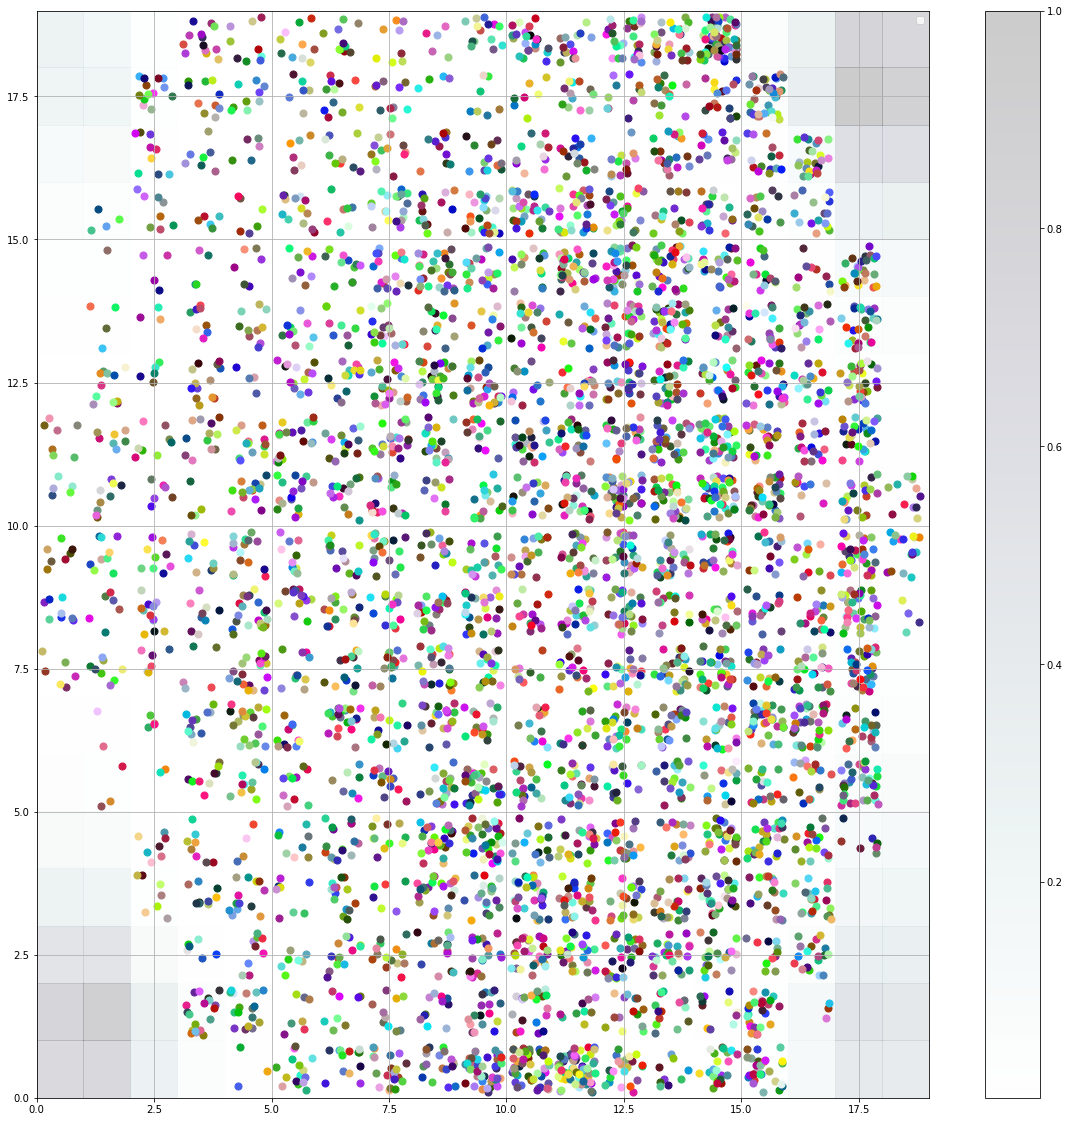

In [3]:
import random 

# Generate label names
label_names = {i: f'Key_{i}' for i in range(0, sampleSize)}

# Generate random colors
colors = ['#' + ''.join(random.choices('0123456789ABCDEF', k=6)) for _ in range(sampleSize)]

#plot som
w_x, w_y = zip(*[somVisual.winner(d) for d in data])
w_x = np.array(w_x)
w_y = np.array(w_y)

plt.figure(figsize=(20, 20))
plt.pcolor(somVisual.distance_map().T, cmap='bone_r', alpha=.2)
plt.colorbar()

for c in np.unique(target):
    idx_target = target==c
    plt.scatter(w_x[idx_target]+.5+(np.random.rand(np.sum(idx_target))-.5)*.8,
                w_y[idx_target]+.5+(np.random.rand(np.sum(idx_target))-.5)*.8, 
                s=50, c=colors[c-1])
    #, label=label_names[c]
plt.legend(loc='upper right')
plt.grid()
plt.show()

# Distribution of SOM Motor

In [4]:
from minisom import MiniSom
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle

sampleSize=5000

#normalize a data set
def min_max_normalize(x):
    min_val = np.min(x, axis=0)
    max_val = np.max(x, axis=0)
    normalized_x = (x - min_val) / (max_val - min_val)
    return normalized_x

# Load data
columns = ['Key','RShoulderPitch', 'RShoulderRoll', 'RElbowYaw', 'RElbowRoll']
data = pd.read_csv('my_project\controllers\my_controller\motor_angles.csv', names=columns, sep=',', engine='python')


target = data['Key'].values

#print(target)
# Remove first column 
data = data[data.columns[1:]]
#print(data)
# Data normalization
data = min_max_normalize(data)
data = data.values

with open('my_project\controllers\my_controller\somAngles.p', 'rb') as infile:
    somAngles = pickle.load(infile)

somAngles.topographic_error(data[:sampleSize])

0.0832

In [ ]:
import random 

# Generate label names
label_names = {i: f'Key_{i}' for i in range(0, sampleSize)}

# Generate random colors
colors = ['#' + ''.join(random.choices('0123456789ABCDEF', k=6)) for _ in range(sampleSize)]

#plot som
w_x, w_y = zip(*[somAngles.winner(d) for d in data])
w_x = np.array(w_x)
w_y = np.array(w_y)

plt.figure(figsize=(20, 20))
plt.pcolor(somAngles.distance_map().T, cmap='bone_r', alpha=.2)
plt.colorbar()

for c in np.unique(target):
    idx_target = target==c
    plt.scatter(w_x[idx_target]+.5+(np.random.rand(np.sum(idx_target))-.5)*.8,
                w_y[idx_target]+.5+(np.random.rand(np.sum(idx_target))-.5)*.8, 
                s=50, c=colors[c-1])
    #, label=label_names[c]
plt.legend(loc='upper right')
plt.grid()
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
